In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

def wrangle (filename, encoding = None, dropna_columnnames = None, change_column_name= None, date_column= None, remove_duplicated_rows_columnsname = None):
    # Loading Data from csv file
    df = pd.read_csv(filename, encoding= encoding)
    ### Get Orders NaN Rows
    df.dropna(subset= dropna_columnnames, inplace=True)

    # Rename Columns
    df = df.rename(columns= change_column_name)
    
    # Change OrderDate and ID Columns type to Date, integer
    df[date_column] = pd.to_datetime(df[date_column])    

    #Drop dupliacted rows
    df = df.drop_duplicates(subset= remove_duplicated_rows_columnsname)

       
    #Strip and lowercase columns names
    df.columns = df.columns.str.strip().str.lower()
    
    for col in df.columns:
        if 'id' in col or 'ordernumber' in col:
            df[col] = df[col].astype(int)
    return df 


orders = wrangle('all_data.csv', encoding= 'latin-1' , 
                 dropna_columnnames= ['OrderID'], 
                 change_column_name= {'City.1' : 'SuppCity', 'Country.1' : 'SuppCountry', 'Phone.1' : 'Supp_Phone'}, 
                 date_column= 'OrderDate', 
                 remove_duplicated_rows_columnsname= ['OrderID'])
orders = orders[['customerid', 'firstname', 'lastname', 'city', 'country', 'orderid', 'ordernumber', 'orderdate', 'totalamount']]


Matplotlib is building the font cache; this may take a moment.


# EDA

In [2]:
### Quintitive data
### describe totalamount

orders.totalamount.describe()

count      830.000000
mean      1631.877819
std       1990.613963
min         12.500000
25%        480.000000
50%       1015.900000
75%       2028.650000
max      17250.000000
Name: totalamount, dtype: float64

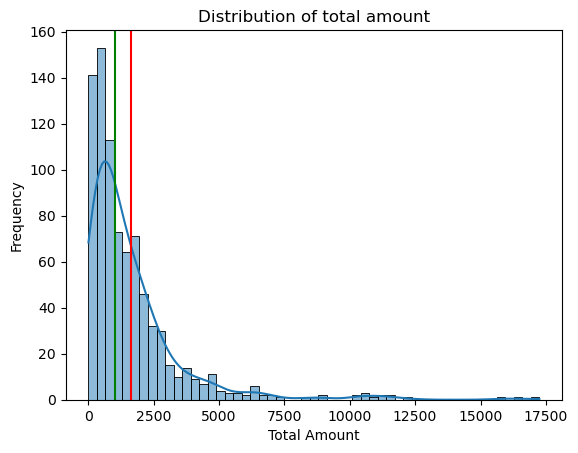

In [3]:
# Data Shape
sns.histplot(orders['totalamount'], kde=True)
plt.title("Distribution of total amount")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
plt.axvline(orders.totalamount.mean(), color="red")
plt.axvline(orders.totalamount.median(), color="green")
plt.show()

In [4]:
min = orders.totalamount.min()
q1 = orders.totalamount.quantile(0.25)
q2 = orders.totalamount.median()
q3 = orders.totalamount.quantile(0.75)
max = orders.totalamount.max()

IQR = q3 - q1

LB = q1 - (1.5 * IQR)
UB = q3 +  (1.5 * IQR)


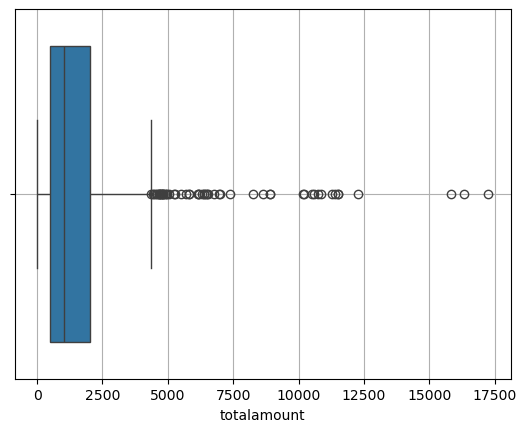

In [5]:
#outliears

sns.boxplot(data=orders , x=orders.totalamount)
plt.grid()

In [6]:
ordesr = orders[orders.totalamount < 15000]

<class 'pandas.DataFrame'>
Index: 830 entries, 0 to 2130
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customerid   830 non-null    int64         
 1   firstname    830 non-null    str           
 2   lastname     830 non-null    str           
 3   city         830 non-null    str           
 4   country      830 non-null    str           
 5   orderid      830 non-null    int64         
 6   ordernumber  830 non-null    int64         
 7   orderdate    830 non-null    datetime64[us]
 8   totalamount  830 non-null    float64       
dtypes: datetime64[us](1), float64(1), int64(3), str(4)
memory usage: 64.8 KB
